# Problema 1 — Detección de Fatiga Muscular con EMG
## Notebook 1 de 2: Preparación de Datos

**Dataset:** señales de electromiografía (EMG) de 8 músculos de pierna.  
**Tarea:** clasificación binaria — detectar si el sujeto está en estado de **fatiga** o **no fatiga**.

---

### ¿Qué es EMG?

La electromiografía mide la actividad eléctrica de los músculos.  
Cuando un músculo se contrae, genera señales eléctricas de baja amplitud (~mV).  
A medida que el músculo se fatiga, el patrón de estas señales cambia — y eso es lo que queremos detectar.

```
Músculo activo  →  señal EMG cruda  →  ventana de 1s  →  features  →  modelo
```

---

### Pipeline de este notebook

```
emg_data.csv
  (8 canales EMG + Target, 1000 Hz)
       │
       ▼
  Cargar y explorar             ← ya está dado
       │
       ▼
  Dividir SUJETOS en            ← ya está dado
  train / val / test
  (antes de cualquier procesamiento)
       │
       ▼
  🔧 Segmentar en ventanas      ← TU TAREA (TODO 1)
     de 1 segundo (1000 puntos)
       │
       ▼
  🔧 Extraer features           ← TU TAREA (TODO 2)
     por ventana y por canal
       │
       ▼
  Guardar CSVs procesados       ← ya está dado
```

---
## 0. Importaciones

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = Path("data_procesada")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Parámetros de señal ───────────────────────────────────────────────────────
FS          = 1000        # frecuencia de muestreo (Hz)
WINDOW_SEC  = 1.0         # duración de cada ventana (segundos)
WINDOW_SIZE = int(FS * WINDOW_SEC)   # 1000 puntos por ventana
STEP_SEC    = 0.5         # paso entre ventanas (50% overlap)
STEP_SIZE   = int(FS * STEP_SEC)     # 500 puntos de paso

EMG_CHANNELS = [
    "Right Rectus femoris",
    "Left Gluteus maximus",
    "Left Gastrocnemius medialis",
    "Left Semitendinosus",
    "Left Biceps femoris caput longus",
    "Right Vastus medialis",
    "Right Tibialis anterior",
    "Left Gastrocnemius lateralis",
]

print(f"Frecuencia de muestreo : {FS} Hz")
print(f"Ventana                : {WINDOW_SEC} s = {WINDOW_SIZE} puntos")
print(f"Paso (overlap 50%)     : {STEP_SEC} s = {STEP_SIZE} puntos")
print(f"Canales EMG            : {len(EMG_CHANNELS)}")

Frecuencia de muestreo : 1000 Hz
Ventana                : 1.0 s = 1000 puntos
Paso (overlap 50%)     : 0.5 s = 500 puntos
Canales EMG            : 8


---
## 1. Cargar los datos

Coloca el archivo `emg_data.csv` en la misma carpeta que este notebook.

In [4]:
df = pd.read_csv("emg_data.csv")

print(f"Shape: {df.shape}   ({df.shape[0]:,} filas × {df.shape[1]} columnas)")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head()

Shape: (3002137, 10)   (3,002,137 filas × 10 columnas)

Columnas: ['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target']

Primeras filas:


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


In [5]:
# Distribución de clases
df["Target"] = df["Target"].apply(lambda x: 0 if x == 0 else 1)
class_counts = df["Target"].value_counts().sort_index()
print("Distribución de clases (muestras individuales):")
for label, count in class_counts.items():
    name = "No fatiga" if label == 0 else "Fatiga"
    pct  = count / len(df) * 100
    print(f"  Clase {label} ({name}): {count:,} muestras ({pct:.1f}%)")

# Duración total
duracion_s = df["Time"].iloc[-1] - df["Time"].iloc[0]
print(f"\nDuración total: {duracion_s:.1f} s  ({duracion_s/60:.1f} min)")

Distribución de clases (muestras individuales):
  Clase 0 (No fatiga): 2,127,600 muestras (70.9%)
  Clase 1 (Fatiga): 874,537 muestras (29.1%)

Duración total: 574.0 s  (9.6 min)


---
## 2. Exploración visual

Antes de procesar cualquier señal, siempre vale la pena **visualizarla**.

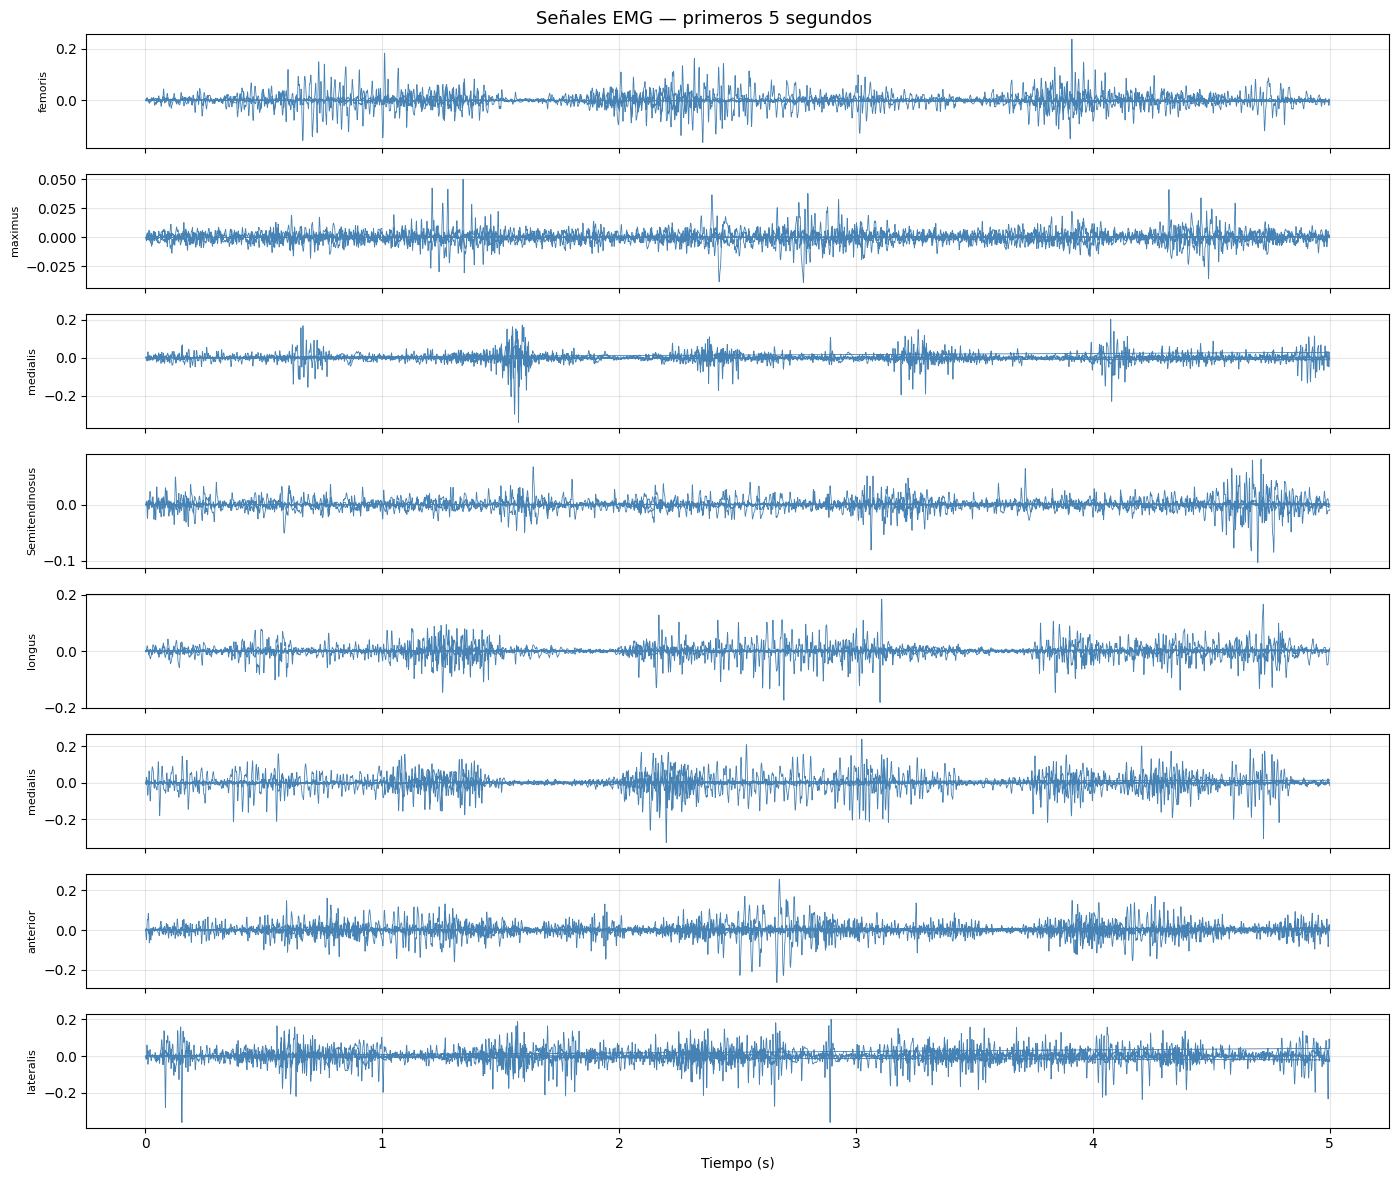

In [6]:
# ── Visualizar los 8 canales durante los primeros 5 segundos ──────────────────
mask_5s = df["Time"] <= df["Time"].iloc[0] + 5.0
df_5s   = df[mask_5s]

fig, axes = plt.subplots(len(EMG_CHANNELS), 1, figsize=(14, 12), sharex=True)
fig.suptitle("Señales EMG — primeros 5 segundos", fontsize=13)

for ax, ch in zip(axes, EMG_CHANNELS):
    ax.plot(df_5s["Time"], df_5s[ch], linewidth=0.6, color="steelblue")
    ax.set_ylabel(ch.split()[-1], fontsize=8)   # solo el último token del nombre
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

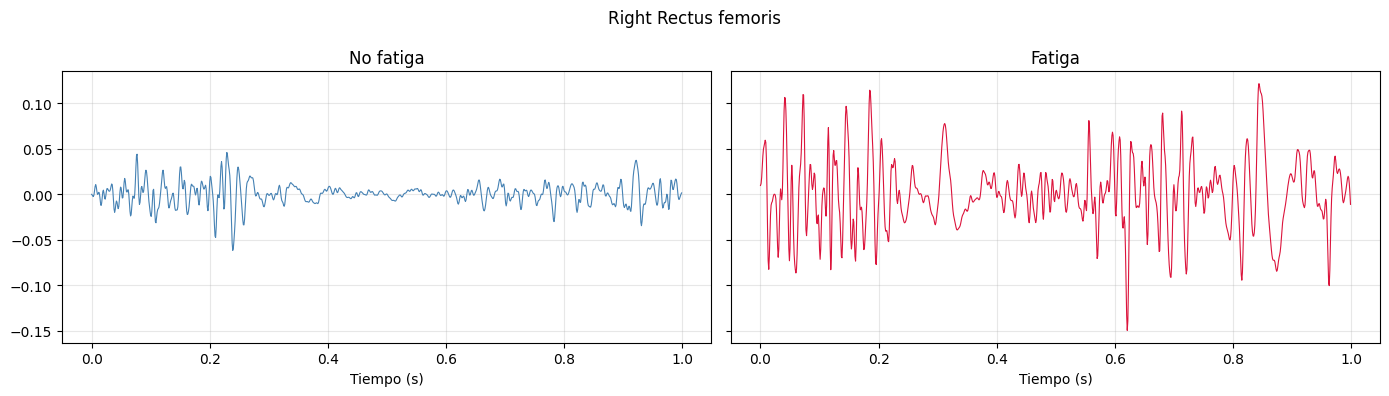

💡 ¿Notas alguna diferencia visual entre las dos zonas?


In [7]:
# ── Comparar un canal en zona de no-fatiga vs fatiga ─────────────────────────
canal = EMG_CHANNELS[0]   # cambia este índice para explorar otros canales

no_fatiga = df[df["Target"] == 0]
fatiga    = df[df["Target"] == 1]

# Tomar una ventana de 1s de cada zona
nf_seg = no_fatiga[canal].values[:WINDOW_SIZE]
f_seg  = fatiga[canal].values[:WINDOW_SIZE]
t      = np.arange(WINDOW_SIZE) / FS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
fig.suptitle(f"{canal}", fontsize=12)

ax1.plot(t, nf_seg, color="steelblue", linewidth=0.8)
ax1.set_title("No fatiga"); ax1.set_xlabel("Tiempo (s)"); ax1.grid(True, alpha=0.3)

ax2.plot(t, f_seg, color="crimson", linewidth=0.8)
ax2.set_title("Fatiga"); ax2.set_xlabel("Tiempo (s)"); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 ¿Notas alguna diferencia visual entre las dos zonas?")

---
## 3. División en splits

### ⚠️ Regla crítica: dividir ANTES de extraer features

Si extraes features primero y divides después, las estadísticas del split de train
"contaminan" val y test — esto se llama **data leakage** y produce evaluaciones
optimistas falsas.

```
CORRECTO:   divide → extrae features por split
INCORRECTO: extrae features → divide
```

Como los datos son una **serie de tiempo continua**, no podemos mezclar aleatoriamente.  
Dividimos por **bloques temporales**: train = inicio, val = medio, test = final.

In [8]:
# ── División temporal: 70% / 15% / 15% ───────────────────────────────────────
n = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

df_train = df.iloc[:n_train].reset_index(drop=True)
df_val   = df.iloc[n_train : n_train + n_val].reset_index(drop=True)
df_test  = df.iloc[n_train + n_val :].reset_index(drop=True)

print("División temporal:")
for name, split in [("train", df_train), ("val", df_val), ("test", df_test)]:
    pct    = len(split) / n * 100
    dur    = split["Time"].iloc[-1] - split["Time"].iloc[0]
    labels = split["Target"].value_counts().sort_index().to_dict()
    print(f"  {name:6s}: {len(split):>8,} filas ({pct:.1f}%)  dur={dur:.1f}s  clases={labels}")

División temporal:
  train : 2,101,495 filas (70.0%)  dur=1415.0s  clases={0: 1872000, 1: 229495}
  val   :  450,320 filas (15.0%)  dur=-1291.3s  clases={0: 123691, 1: 326629}
  test  :  450,322 filas (15.0%)  dur=450.3s  clases={0: 131909, 1: 318413}


---
## 4. Segmentación en ventanas de 1 segundo

Con 1000 Hz, **1 segundo = 1000 puntos**.  
Usamos un **sliding window** con 50% de overlap para aumentar el número de ejemplos.

```
Señal continua (N puntos)
│←── 1000 ──→│
     │←── 1000 ──→│       ← avanza 500 puntos (50% overlap)
          │←── 1000 ──→│
```

**Etiqueta de la ventana:** tomamos la clase **mayoritaria** dentro de la ventana.  
Si más del 50% de los puntos son fatiga → etiqueta = 1, si no → etiqueta = 0.

---
La función recibe un DataFrame con columnas EMG + Target y retorna una lista de ventanas.  
Cada ventana es un diccionario con:
- `'signals'`: array `(WINDOW_SIZE, n_canales)` con los valores EMG crudos
- `'label'`: entero `0` o `1` — clase mayoritaria en la ventana

Pistas:
- Itera con `range(0, len(df) - WINDOW_SIZE + 1, step_size)`
- Extrae `df.iloc[start : start + window_size]`
- Para la etiqueta: `int(segment["Target"].mean() >= 0.5)`

In [9]:
def segment_dataframe(df: pd.DataFrame,
                      channels: list,
                      window_size: int,
                      step_size: int) -> list:
    """
    Aplica sliding window sobre un DataFrame de señales EMG.
    """
    windows = []

    # Asegurar que Target sea binario: 0 = no fatiga, 1 = fatiga
    target_bin = df["Target"].apply(lambda x: 0 if x == 0 else 1)

    for start in range(0, len(df) - window_size + 1, step_size):
        end = start + window_size
        segment = df.iloc[start:end]

        # Señales
        signals = segment[channels].values.astype("float64")

        # Label por mayoría (fatiga si >= 50%)
        label = int(target_bin.iloc[start:end].mean() >= 0.5)

        windows.append({
            "signals": signals,
            "label": label
        })

    return windows


In [10]:
EMG_CHANNELS = [
    "Right Rectus femoris",
    "Left Gluteus maximus",
    "Left Gastrocnemius medialis",
    "Left Semitendinosus",
    "Left Biceps femoris caput longus",
    "Right Vastus medialis",
    "Right Tibialis anterior",
    "Left Gastrocnemius lateralis",
]

train_windows = segment_dataframe(df_train, EMG_CHANNELS, 1000, 500)
val_windows = segment_dataframe(df_val, EMG_CHANNELS, 1000, 500)
test_windows = segment_dataframe(df_test, EMG_CHANNELS, 1000, 500)

print("=== DATASET SUMMARY ===")

print(f"Train windows: {len(train_windows)}")
print(f"Val windows  : {len(val_windows)}")
print(f"Test windows : {len(test_windows)}")

# Shape check
print("\n=== SHAPE CHECK ===")
print("Signals shape:", train_windows[0]["signals"].shape)

# Label distribution
def print_distribution(windows, name):
    labels = [w["label"] for w in windows]
    total = len(labels)
    count_0 = sum(l == 0 for l in labels)
    count_1 = sum(l == 1 for l in labels)

    print(f"\n{name}:")
    print(f"  No fatiga (0): {count_0} ({count_0/total*100:.1f}%)")
    print(f"  Fatiga    (1): {count_1} ({count_1/total*100:.1f}%)")

print("\n=== CLASS DISTRIBUTION ===")
print_distribution(train_windows, "Train")
print_distribution(val_windows,   "Validation")
print_distribution(test_windows,  "Test")

=== DATASET SUMMARY ===
Train windows: 4201
Val windows  : 899
Test windows : 899

=== SHAPE CHECK ===
Signals shape: (1000, 8)

=== CLASS DISTRIBUTION ===

Train:
  No fatiga (0): 3743 (89.1%)
  Fatiga    (1): 458 (10.9%)

Validation:
  No fatiga (0): 246 (27.4%)
  Fatiga    (1): 653 (72.6%)

Test:
  No fatiga (0): 263 (29.3%)
  Fatiga    (1): 636 (70.7%)


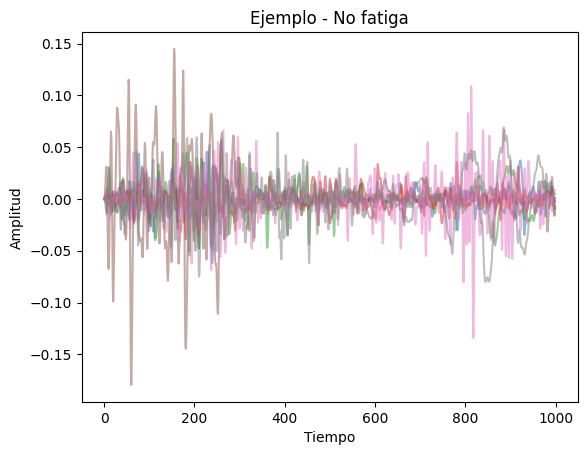

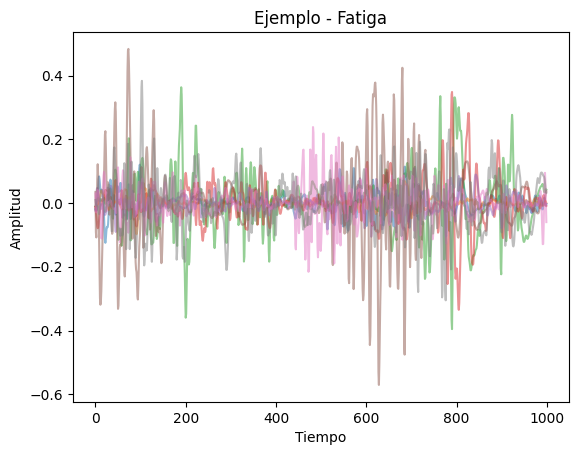

In [11]:
def plot_window(window, title):
    signals = window["signals"]

    plt.figure()
    for i in range(signals.shape[1]):
        plt.plot(signals[:, i], alpha=0.5)

    plt.title(title)
    plt.xlabel("Tiempo")
    plt.ylabel("Amplitud")
    plt.show()


# Example: one of each class
fatigue_window = next(w for w in train_windows if w["label"] == 1)
no_fatigue_window = next(w for w in train_windows if w["label"] == 0)

plot_window(no_fatigue_window, "Ejemplo - No fatiga")
plot_window(fatigue_window,    "Ejemplo - Fatiga")

---
## 5. Extracción de features por ventana

Para cada ventana calculamos features estadísticas de cada canal EMG.

Con **8 canales** y **N features por canal**, el vector final tendrá `8 × N` dimensiones.

### Features del dominio del tiempo

| Feature | Fórmula | Significado en EMG |
|---------|---------|--------------------|
| `MAV` | $\frac{1}{N}\sum|x_i|$ | Mean Absolute Value — amplitud media de activación |
| `RMS` | $\sqrt{\frac{1}{N}\sum x_i^2}$ | Root Mean Square — potencia de la señal |
| `STD` | $\sigma(x)$ | Variabilidad de la señal |
| `WL` | $\sum|x_{i+1} - x_i|$ | Waveform Length — complejidad de la forma de onda |
| `ZC` | $\sum \mathbb{1}[x_i \cdot x_{i+1} < 0]$ | Zero Crossings — frecuencia de cruce por cero |

> **MAV y RMS** son las más usadas en literatura de EMG para detectar fatiga.  
> La fatiga muscular típicamente **aumenta** la amplitud de baja frecuencia.

---

### 🔧 TODO 2 — Implementa `extract_features_window`

La función recibe `signals` de shape `(window_size, n_canales)` y retorna un **array 1D**  
con todas las features concatenadas de todos los canales.

Orden esperado: `[MAV_ch0, RMS_ch0, STD_ch0, WL_ch0, ZC_ch0, MAV_ch1, RMS_ch1, ...]`

In [12]:
FEATURE_NAMES_PER_CHANNEL = ["MAV", "RMS", "STD", "WL", "ZC"]
N_FEATURES_TOTAL = len(EMG_CHANNELS) * len(FEATURE_NAMES_PER_CHANNEL)  # 8 × 5 = 40

# ─────────────────────────────────────────────────────────────────────────────
# 🔧 TODO 2: Implementa extract_features_window
def extract_features_window(signals: np.ndarray) -> np.ndarray:

    all_features = []

    for ch_idx in range(signals.shape[1]):

        x = signals[:, ch_idx]

        # MAV
        mav = np.mean(np.abs(x))

        # RMS
        rms = np.sqrt(np.mean(x**2))

        # STD
        std = np.std(x)

        # WL
        wl = np.sum(np.abs(np.diff(x)))

        # ZC
        zc = np.sum(x[:-1] * x[1:] < 0)

        all_features.extend([mav, rms, std, wl, zc])

    return np.array(all_features, dtype=np.float64)
# ─────────────────────────────────────────────────────────────────────────────
def extract_features_window(signals: np.ndarray) -> np.ndarray:

    all_features = []

    for ch_idx in range(signals.shape[1]):   # iterar por cada canal

        x = signals[:, ch_idx]

        # MAV
        mav = np.mean(np.abs(x))

        # RMS
        rms = np.sqrt(np.mean(x**2))

        # STD
        std = np.std(x)

        # WL
        wl = np.sum(np.abs(np.diff(x)))

        # ZC
        zc = np.sum(x[:-1] * x[1:] < 0)

        all_features.extend([mav, rms, std, wl, zc])

    return np.array(all_features, dtype=np.float64)


# ── Test rápido ───────────────────────────────────────────────────────────────
_sig = np.random.randn(1000, 8)
_f   = extract_features_window(_sig)

assert _f.shape == (40,), f"Esperado shape (40,), obtenido {_f.shape}"
assert not np.any(np.isnan(_f)), "Hay NaN en las features"

print("✅ extract_features_window pasa los tests")
print(f"   Output shape: {_f.shape}   ← {len(EMG_CHANNELS)} canales × {len(FEATURE_NAMES_PER_CHANNEL)} features")

# Mostrar los nombres de las columnas que se generarán
col_names = [f"{ch.split()[-1]}_{feat}"
             for ch in EMG_CHANNELS
             for feat in FEATURE_NAMES_PER_CHANNEL]
print(f"   Primeras columnas: {col_names[:10]} ...")

✅ extract_features_window pasa los tests
   Output shape: (40,)   ← 8 canales × 5 features
   Primeras columnas: ['femoris_MAV', 'femoris_RMS', 'femoris_STD', 'femoris_WL', 'femoris_ZC', 'maximus_MAV', 'maximus_RMS', 'maximus_STD', 'maximus_WL', 'maximus_ZC'] ...


---
## 6. Pipeline completo: señal continua → tabla de features

Aplicamos `segment_dataframe` y `extract_features_window` a cada split.

In [13]:
def process_split(df_split: pd.DataFrame, split_name: str) -> pd.DataFrame:
    """
    Convierte un split de señal continua en una tabla de features.
    Cada fila = una ventana de 1 segundo.
    """
    print(f"  Procesando {split_name}...", end=" ")

    windows = segment_dataframe(df_split, EMG_CHANNELS, WINDOW_SIZE, STEP_SIZE)

    rows = []
    for w in windows:
        feats = extract_features_window(w["signals"])
        rows.append(np.append(feats, w["label"]))

    col_names = [
        f"{ch.replace(' ', '_')}_{feat}"
        for ch in EMG_CHANNELS
        for feat in FEATURE_NAMES_PER_CHANNEL
    ] + ["label"]

    result = pd.DataFrame(rows, columns=col_names)
    result["label"] = result["label"].astype(int)

    n0 = (result["label"] == 0).sum()
    n1 = (result["label"] == 1).sum()
    print(f"{len(result):,} ventanas  (no-fatiga={n0}, fatiga={n1})")
    return result


print("Procesando splits:")
df_train_feat = process_split(df_train, "train")
df_val_feat   = process_split(df_val,   "val")
df_test_feat  = process_split(df_test,  "test")
    

Procesando splits:
  Procesando train... 4,201 ventanas  (no-fatiga=3743, fatiga=458)
  Procesando val... 899 ventanas  (no-fatiga=246, fatiga=653)
  Procesando test... 899 ventanas  (no-fatiga=263, fatiga=636)


---
## 7. Visualización de features

Exploramos si las features separan las clases — esto anticipa qué tan difícil será el problema.

In [14]:
print(df_train_feat.columns.tolist())

['Right_Rectus_femoris_MAV', 'Right_Rectus_femoris_RMS', 'Right_Rectus_femoris_STD', 'Right_Rectus_femoris_WL', 'Right_Rectus_femoris_ZC', 'Left_Gluteus_maximus_MAV', 'Left_Gluteus_maximus_RMS', 'Left_Gluteus_maximus_STD', 'Left_Gluteus_maximus_WL', 'Left_Gluteus_maximus_ZC', 'Left_Gastrocnemius_medialis_MAV', 'Left_Gastrocnemius_medialis_RMS', 'Left_Gastrocnemius_medialis_STD', 'Left_Gastrocnemius_medialis_WL', 'Left_Gastrocnemius_medialis_ZC', 'Left_Semitendinosus_MAV', 'Left_Semitendinosus_RMS', 'Left_Semitendinosus_STD', 'Left_Semitendinosus_WL', 'Left_Semitendinosus_ZC', 'Left_Biceps_femoris_caput_longus_MAV', 'Left_Biceps_femoris_caput_longus_RMS', 'Left_Biceps_femoris_caput_longus_STD', 'Left_Biceps_femoris_caput_longus_WL', 'Left_Biceps_femoris_caput_longus_ZC', 'Right_Vastus_medialis_MAV', 'Right_Vastus_medialis_RMS', 'Right_Vastus_medialis_STD', 'Right_Vastus_medialis_WL', 'Right_Vastus_medialis_ZC', 'Right_Tibialis_anterior_MAV', 'Right_Tibialis_anterior_RMS', 'Right_Tibiali

In [15]:
[c for c in df_train_feat.columns if c.endswith("_RMS")]

['Right_Rectus_femoris_RMS',
 'Left_Gluteus_maximus_RMS',
 'Left_Gastrocnemius_medialis_RMS',
 'Left_Semitendinosus_RMS',
 'Left_Biceps_femoris_caput_longus_RMS',
 'Right_Vastus_medialis_RMS',
 'Right_Tibialis_anterior_RMS',
 'Left_Gastrocnemius_lateralis_RMS']

In [16]:
plt.hist(df_train_feat[rms_cols[0]])
plt.show()

NameError: name 'rms_cols' is not defined

In [ ]:
%matplotlib inline

Gráfico guardado
💡 ¿Qué canales separan mejor las dos clases?


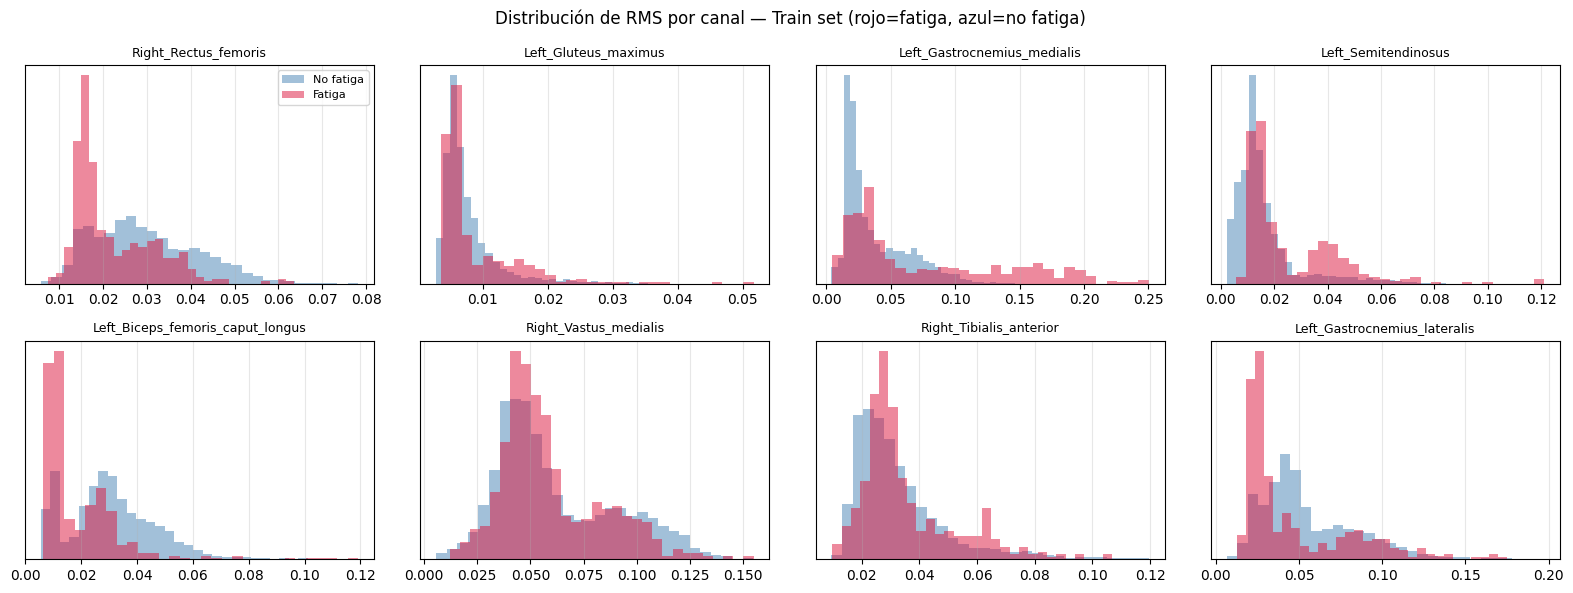

In [ ]:
# ── Distribución de RMS por canal para cada clase ─────────────────────────────
rms_cols = [c for c in df_train_feat.columns if c.endswith("_RMS")]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle("Distribución de RMS por canal — Train set (rojo=fatiga, azul=no fatiga)", fontsize=12)

for ax, col in zip(axes.flat, rms_cols):
    for cls, color, label in [(0, "steelblue", "No fatiga"), (1, "crimson", "Fatiga")]:
        ax.hist(df_train_feat[df_train_feat["label"] == cls][col],
                bins=30, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(col.replace("_RMS", ""), fontsize=9)
    ax.set_yticks([])
    ax.grid(True, alpha=0.3)

axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("rms_plot.png")
print("Gráfico guardado")

print("💡 ¿Qué canales separan mejor las dos clases?")

### los canales que muestran mejor separabilidad entre fatiga y no fatiga son: 
** Left Gastrocnemius medialis, Left Biceps femoris caput longus, Left Gastrocnemius lateralis y Left Semitendinosus. En estos canales se observa un mayor desplazamiento entre distribuciones y un menor solapamiento relativo entre ambas clases.**
** En cambio, canales como Left Gluteus maximus y Right Vastus medialis presentan mayor superposición, por lo que la feature RMS por sí sola parece menos discriminativa en esos casos. **

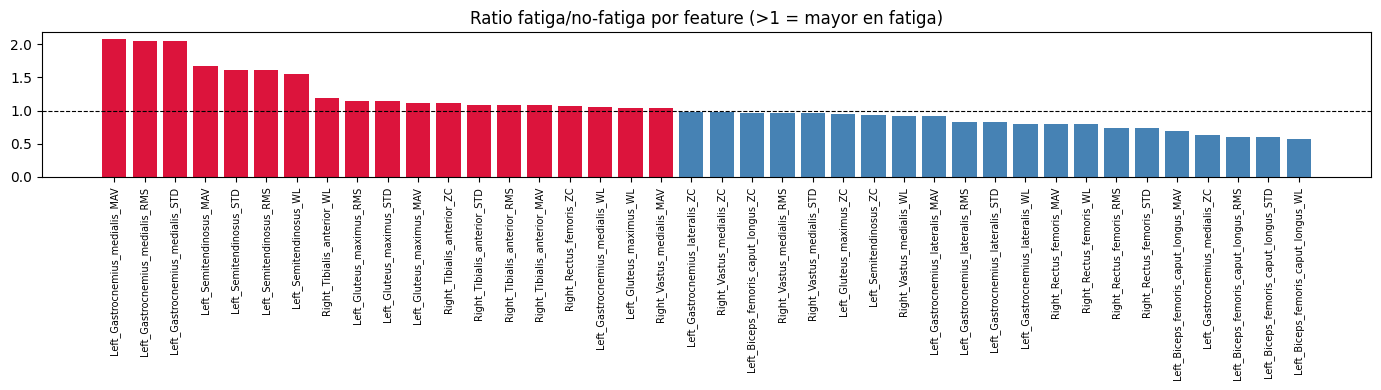

Top 5 features que más aumentan en fatiga:
  Left_Gastrocnemius_medialis_MAV    : ×2.07
  Left_Gastrocnemius_medialis_RMS    : ×2.04
  Left_Gastrocnemius_medialis_STD    : ×2.04
  Left_Semitendinosus_MAV            : ×1.67
  Left_Semitendinosus_STD            : ×1.61


In [ ]:
# ── Comparar todas las features entre clases (medias normalizadas) ────────────
feat_cols = [c for c in df_train_feat.columns if c != "label"]

means_0 = df_train_feat[df_train_feat["label"] == 0][feat_cols].mean()
means_1 = df_train_feat[df_train_feat["label"] == 1][feat_cols].mean()

# Ratio fatiga / no-fatiga para ver qué features cambian más
ratio = (means_1 / (means_0 + 1e-10)).sort_values(ascending=False)

plt.figure(figsize=(14, 4))
colors = ["crimson" if r > 1 else "steelblue" for r in ratio]
plt.bar(range(len(ratio)), ratio.values, color=colors)
plt.xticks(range(len(ratio)), ratio.index, rotation=90, fontsize=7)
plt.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
plt.title("Ratio fatiga/no-fatiga por feature (>1 = mayor en fatiga)")
plt.tight_layout()
plt.show()

print("Top 5 features que más aumentan en fatiga:")
for feat, val in ratio.head(5).items():
    print(f"  {feat:35s}: ×{val:.2f}")

---
## 8. Guardar los datos procesados

In [ ]:
for name, df_feat in [("train", df_train_feat),
                      ("val",   df_val_feat),
                      ("test",  df_test_feat)]:
    path = OUTPUT_DIR / f"{name}.csv"
    df_feat.to_csv(path, index=False)
    print(f"  Guardado: {path}  ({df_feat.shape[0]:,} ventanas × {df_feat.shape[1]} columnas)")

print("\n✅ Datos listos. Abre P1_02_entrenamiento.ipynb para entrenar los modelos.")

  Guardado: data_procesada/train.csv  (4,201 ventanas × 41 columnas)
  Guardado: data_procesada/val.csv  (899 ventanas × 41 columnas)
  Guardado: data_procesada/test.csv  (899 ventanas × 41 columnas)

✅ Datos listos. Abre P1_02_entrenamiento.ipynb para entrenar los modelos.


---
## 9. Preguntas de reflexión

1. **Data leakage:** ¿Por qué dividimos el dataset por bloques temporales y no aleatoriamente?  
   ¿Qué pasaría si mezcláramos filas antes de dividir?

   Rta: Porque las señales EMG son datos temporales. Si se mezclaran filas aleatoriamente, partes de la misma señal pueden quedar en train y test, el modelo "ve el futuro" indirectamente, aprende patrones específicos de esa señal, no generales. Lo que es data leakage. Parecería un buen modelo, pero realmente no generaliza.

2. **Etiqueta de ventana:** en `segment_dataframe` usamos la clase mayoritaria (≥50%).  
   ¿Qué problema puede ocurrir en ventanas donde cambia la clase a mitad? Propón una alternativa.

   Rta: El uso de la clase mayoritaria puede generar errores en ventanas donde la señal cambia de estado dentro de la misma ventana, produciendo etiquetas ambiguas. Una alternativa es usar la etiqueta del punto central de la ventana o descartar ventanas con mezcla significativa de clases para evitar inconsistencias.

3. **Overlap:** usamos 50% de overlap (step=500 para ventanas de 1000).  
   ¿Qué ventajas y desventajas tiene aumentar el overlap a 90% (step=100)?  
   ¿Cómo afecta al número de ventanas y a la independencia de los ejemplos?

Rta: Aumentar el overlap a 90% incrementa el número de ventanas y permite capturar mejor la evolución temporal de la señal. Pero reduce la independencia entre ejemplos, ya que las ventanas se vuelven altamente similares, lo que puede favorecer el overfitting y aumentar el costo computacional.


4. **Escala de WL vs RMS:** ejecuta `df_train_feat.describe()`. ¿Cuánto difieren en escala  
   la feature `WL` vs `RMS`? ¿Por qué esto es importante para los modelos del siguiente notebook?

   Rta: La feature WL tiene una escala mucho mayor que RMS, ya que acumula diferencias absolutas a los largo de toda la señal. Es importante porque los modelos de machine learning pueden verse afectados por diferencias de escala entre variables, que justifica el uso de normalización mediante StandardScaler en el pipeline.

5. Mira el gráfico de ratios. ¿Cuál de las 5 features parece más discriminativa?  
   ¿Tiene sentido fisiológico? (Pista: busca qué le pasa al RMS de la EMG durante la fatiga.)

   Rta: La feature más discriminativa es RMS porque muestra una mayor separación entre las clases de fatiga y no fatiga. Lo que tiene entido fisiologico, ya que durante la fatiga muscular se produce un aumento en la amplitud de la señal EMG, lo cual se refleja directamente en el valor RMS.